# Vancouver 2003 Crime Data Analysis

This project analyzes crime data in Vancouver to identify trends in crime types, locations, and times.

**Tools Used**:
- Python
- Pandas
- Matplotlib
- sqlite
- Jupyter Notebook

## Objective

The goal of this analysis is to identify crime patterns in Vacouver in the year 2003.

Questions we want to answer:

- Which neighborhoods have the most crime?
- What types of crimes occur most often?
- Are there specific times when crimes occur more frequently?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

## Executing the SQL File and Loading Dataset

We first connect to the "crimes" database and execute the "van_crime_2003.sql" file to create our dataset.
Next, we create a **pandas dataframe** by querying the "van_crimes" table through selecting every element and writing the result into a csv.


In [2]:
# connect to database
conn = sqlite3.connect("crimes.db")
cursor = conn.cursor()

# execute SQL file
with open("van_crime_2003.sql", "r", encoding="utf-8") as f:
    cursor.executescript(f.read())

conn.commit()

# check tables
tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print("Tables:", tables)

Tables: [('van_crimes',)]


In [3]:
# Create a dataframe of "van_crimes" table
van_crimes_df = pd.read_sql_query("SELECT * FROM van_crimes", conn)

print(van_crimes_df.head())

                 TYPE  YEAR  MONTH   DAY  HOUR  MINUTE         HUNDRED_BLOCK  \
0  Theft from Vehicle  2003      6  28.0  13.0    30.0         8XX EXPO BLVD   
1  Theft from Vehicle  2003     11  17.0  16.0     0.0           56XX OAK ST   
2  Theft from Vehicle  2003     12  30.0  14.0     0.0  85XX STANLEY PARK DR   
3    Theft of Vehicle  2003      1  15.0  14.0    45.0        6XX W 41ST AVE   
4  Theft from Vehicle  2003     12  28.0  16.0    45.0  85XX STANLEY PARK DR   

               NEIGHBOURHOOD          X           Y  
0  Central Business District  491771.63  5458295.01  
1               South Cambie  490682.32  5453536.96  
2               Stanley Park  489104.19  5460347.36  
3                   Oakridge  491372.94  5453422.83  
4               Stanley Park  489104.19  5460347.36  


In [4]:
van_crimes_df.to_csv('van_crimes.csv', index=False) # Writing the "van_crimes" table into a csv

In [5]:
van_crimes_df.head()

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y
0,Theft from Vehicle,2003,6,28.0,13.0,30.0,8XX EXPO BLVD,Central Business District,491771.63,5458295.01
1,Theft from Vehicle,2003,11,17.0,16.0,0.0,56XX OAK ST,South Cambie,490682.32,5453536.96
2,Theft from Vehicle,2003,12,30.0,14.0,0.0,85XX STANLEY PARK DR,Stanley Park,489104.19,5460347.36
3,Theft of Vehicle,2003,1,15.0,14.0,45.0,6XX W 41ST AVE,Oakridge,491372.94,5453422.83
4,Theft from Vehicle,2003,12,28.0,16.0,45.0,85XX STANLEY PARK DR,Stanley Park,489104.19,5460347.36


## Dataset Exploration

Before cleaning the data, we first examine the structure of the data using **commands** such as:

- .info()
- columns
- shape
- size
- .describe()

In [6]:
van_crimes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TYPE           250 non-null    str    
 1   YEAR           250 non-null    int64  
 2   MONTH          250 non-null    int64  
 3   DAY            250 non-null    float64
 4   HOUR           245 non-null    float64
 5   MINUTE         245 non-null    float64
 6   HUNDRED_BLOCK  250 non-null    str    
 7   NEIGHBOURHOOD  245 non-null    str    
 8   X              250 non-null    float64
 9   Y              250 non-null    float64
dtypes: float64(5), int64(2), str(3)
memory usage: 19.7 KB


In [7]:
# we see that the domain for each column matches what is expected from this dataset, for example, that max for hour column is 23.
van_crimes_df.describe()

,YEAR,MONTH,DAY,HOUR,MINUTE,X,Y
count,250.0,250.000000,250.000000,245.000000,245.000000,250.0000,2.500000e+02
mean,2003.0,6.428000,15.200000,13.897959,13.338776,481879.7744,5.347402e+06
std,0.0,3.448534,8.765119,5.884283,16.849488,69012.6623,7.654520e+05
min,2003.0,1.000000,1.000000,0.000000,0.000000,0.0000,0.000000e+00
25%,2003.0,4.000000,8.000000,11.000000,0.000000,490382.5800,5.453423e+06
50%,2003.0,6.000000,16.000000,15.000000,0.000000,491372.9400,5.456920e+06
75%,2003.0,9.000000,23.000000,18.000000,30.000000,492495.1000,5.458720e+06
max,2003.0,12.000000,31.000000,23.000000,59.000000,497521.2700,5.460347e+06


In [8]:
van_crimes_df.columns

Index(['TYPE', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'HUNDRED_BLOCK',
       'NEIGHBOURHOOD', 'X', 'Y'],
      dtype='str')

In [9]:
van_crimes_df.shape

(250, 10)

In [10]:
van_crimes_df.size

2500

## Data Cleaning

We then check for missing values, duplicates, and invalid data.

Making sure that data is not out of the expected domain is imperative.

In [11]:
van_crimes_df.isnull().sum()

TYPE             0
YEAR             0
MONTH            0
DAY              0
HOUR             5
MINUTE           5
HUNDRED_BLOCK    0
NEIGHBOURHOOD    5
X                0
Y                0
dtype: int64

In [12]:
van_crimes_df.duplicated().sum()

np.int64(1)

In [13]:
van_crimes_df[van_crimes_df['HOUR'] > 24] # Check if any rows have a value greater than 24 in the "HOUR" column

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y


In [14]:
#These specific rows have null values to hide
van_crimes_df[van_crimes_df.isnull().any(axis=1)]

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y
42,Offence Against a Person,2003,7,15.0,NaN,NaN,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0
49,Offence Against a Person,2003,5,14.0,NaN,NaN,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0
81,Offence Against a Person,2003,8,3.0,NaN,NaN,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0
142,Offence Against a Person,2003,6,19.0,NaN,NaN,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0
145,Offence Against a Person,2003,6,19.0,NaN,NaN,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0


The table above shows all the rows that contain null values. We see that they are null to protect privacy, meaning they can be dropped from the **van_crimes** table.

In [15]:
van_crimes_df.dropna(inplace = True)

In [22]:
van_crimes_df.isnull().sum()

TYPE             0
YEAR             0
MONTH            0
DAY              0
HOUR             0
MINUTE           0
HUNDRED_BLOCK    0
NEIGHBOURHOOD    0
X                0
Y                0
dtype: int64

## Crime Analysis

We now analyze patterns in crime types, locations, and time

**Crimes Per Neighborhood**

In [16]:
neighborhood_count = van_crimes_df['NEIGHBOURHOOD'].value_counts()
neighborhood_count

NEIGHBOURHOOD
Oakridge                     45
West End                     40
Central Business District    29
Stanley Park                 24
Grandview-Woodland           16
Kensington-Cedar Cottage     15
Mount Pleasant               15
Marpole                      12
Fairview                      8
South Cambie                  6
Kitsilano                     6
Riley Park                    6
Hastings-Sunrise              5
Sunset                        4
Killarney                     3
Strathcona                    2
Renfrew-Collingwood           2
West Point Grey               2
Arbutus Ridge                 1
Shaughnessy                   1
Kerrisdale                    1
Dunbar-Southlands             1
Victoria-Fraserview           1
Name: count, dtype: int64

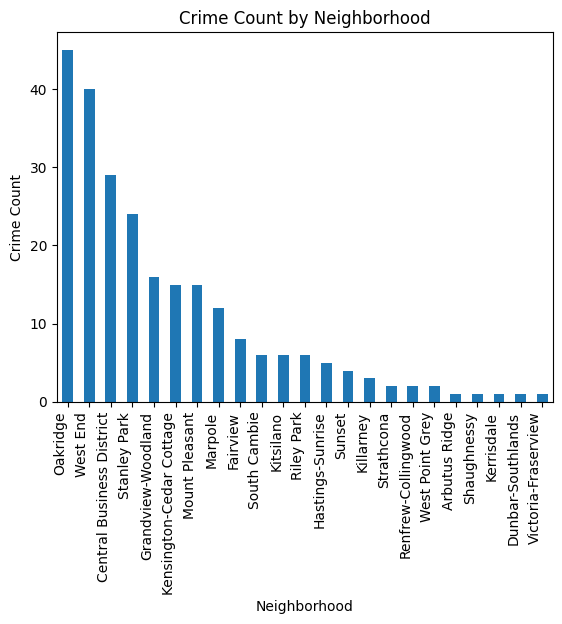

In [17]:
neighborhood_count.plot(kind="bar")
plt.figsize=(12, 6)
plt.title("Crime Count by Neighborhood")
plt.xlabel('Neighborhood')
plt.ylabel('Crime Count')
plt.xticks(rotation = 90, ha='right')   
plt.show()

`**Crime Types**

In [18]:
crime_type = van_crimes_df['TYPE'].value_counts()
crime_type

TYPE
Theft of Vehicle                                        100
Theft from Vehicle                                       78
Break and Enter Residential/Other                        34
Mischief                                                 29
Vehicle Collision or Pedestrian Struck (with Injury)      4
Name: count, dtype: int64

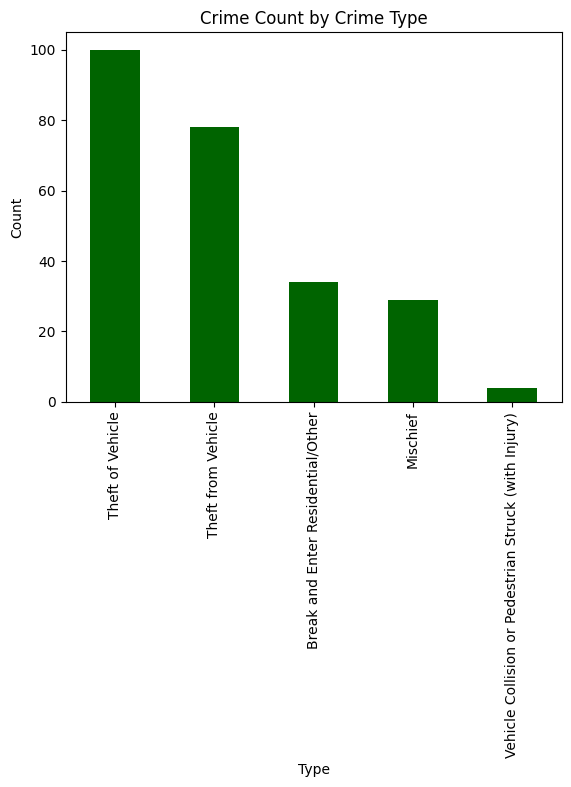

In [19]:
crime_type.plot(kind="bar", color = 'darkgreen')
plt.figsize=(12, 6)
plt.title("Crime Count by Crime Type")
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)   
plt.show()

**Frequency of Crime by Hour Per Day**

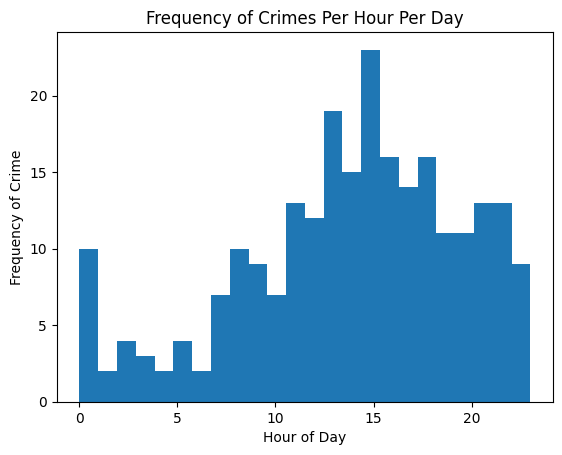

In [20]:
hours = van_crimes_df['HOUR']
plt.hist(hours, bins=24)
plt.title('Frequency of Crimes Per Hour Per Day')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency of Crime')
plt.show()

## Key Insights

- Oakridge has the highest number of reported crimes in 2003
- Theft from vehicle appears to be the crime most conducted in 2003
- More crimes occur during the afternoon and evening then the morning and before dawn

## Conclusion

This analysis identified key crime trends in Vancouver in the year 2003

Future Improve could include:

- Better division of personnel for neighborhoods with higher crime rate
- Geographic heatmaps
- Predictive modeling